In [1]:
!pip install -q transformers datasets peft accelerate bitsandbytes trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 45.9 MB/s eta 0:00:00


In [3]:
from datasets import load_dataset

verbatim_dataset = load_dataset(
    "json",
    data_files="mmlu_verbatim.json",
    split="train"
)

paraphrased_dataset = load_dataset(
    "json",
    data_files="mmlu_paraphrased_final.json",
    split="train"
)

print(len(verbatim_dataset))
print(len(paraphrased_dataset))

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

200
115


In [4]:
def format_example(example):

    choices = example["choices"]

    prompt = f"""
Question: {example['question']}

A) {choices[0]}
B) {choices[1]}
C) {choices[2]}
D) {choices[3]}

Answer:
"""

    answer_letter = ["A","B","C","D"][example["answer"]]

    return {"text": prompt + answer_letter}


verbatim_dataset = verbatim_dataset.map(format_example)
paraphrased_dataset = paraphrased_dataset.map(format_example)

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/115 [00:00<?, ? examples/s]

In [11]:
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
import torch

model_name = "microsoft/phi-2"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

# Fix tokenizer padding
tokenizer.pad_token = tokenizer.eos_token

# Load config first
config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)

# FIX: add pad token to config
config.pad_token_id = tokenizer.eos_token_id

# Now load model with fixed config
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    config=config,
    dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

print("✅ Phi-2 loaded successfully")

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Phi-2 loaded successfully


In [12]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj","v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

In [13]:
def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

verbatim_dataset = verbatim_dataset.map(tokenize)
paraphrased_dataset = paraphrased_dataset.map(tokenize)

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/115 [00:00<?, ? examples/s]

In [27]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=1,   # IMPORTANT
    gradient_accumulation_steps=8,   # simulate bigger batch
    num_train_epochs=3,
    logging_steps=10,
    save_strategy="epoch",
    fp16=True
)

In [28]:
def tokenize_function(example):
    text = example["question"]

    tokens = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=128
    )

    tokens["labels"] = tokens["input_ids"].copy()

    return tokens

In [29]:
verbatim_dataset = verbatim_dataset.map(tokenize_function)
verbatim_dataset.set_format(type="torch")

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [31]:
import torch
torch.cuda.empty_cache()

In [19]:
trainer.save_model("model_verbatim")

In [20]:
paraphrased_dataset

Dataset({
    features: ['subject', 'question', 'choices', 'answer', 'split_type', 'text', 'input_ids', 'attention_mask'],
    num_rows: 115
})

In [21]:
def tokenize_function(example):
    text = example["question"]

    tokens = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=128
    )

    tokens["labels"] = tokens["input_ids"].copy()

    return tokens


paraphrased_dataset = paraphrased_dataset.map(tokenize_function)
paraphrased_dataset.set_format(type="torch")

Map:   0%|          | 0/115 [00:00<?, ? examples/s]

In [23]:
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    config=config,
    dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

In [33]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=paraphrased_dataset
)

In [32]:
import torch
torch.cuda.empty_cache()

In [35]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    logging_steps=10,
    save_strategy="epoch",
    fp16=False   # IMPORTANT FIX
)

In [36]:
import torch
torch.cuda.empty_cache()

In [38]:
!pip install peft accelerate bitsandbytes

In [39]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj","k_proj","v_proj","dense"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 10,485,760 || all params: 2,790,169,600 || trainable%: 0.3758


In [40]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_steps=10,
    save_strategy="epoch",
    fp16=False
)

In [41]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=paraphrased_dataset
)

trainer.train()

Step,Training Loss
10,5.161353
20,4.481531
30,2.772733
40,1.607433
50,1.192647
60,0.981857
70,1.033908
80,1.123351


TrainOutput(global_step=87, training_loss=2.194964693880629, metrics={'train_runtime': 74.4927, 'train_samples_per_second': 4.631, 'train_steps_per_second': 1.168, 'total_flos': 704554500096000.0, 'train_loss': 2.194964693880629, 'epoch': 3.0})

In [42]:
trainer.save_model("model_paraphrased")

In [47]:
from google.colab import files
uploaded = files.upload()

Saving mmlu_sampled_600.json to mmlu_sampled_600.json


In [48]:
import pandas as pd

df = pd.read_json("mmlu_sampled_600.json", lines=True)

print(df.head())

                                            question                 subject  \
0       The disco band ABBA comes from what country?           miscellaneous   
1  Which following pair of substances can be used...   high_school_chemistry   
2  If the finite group G contains a subgroup of o...     college_mathematics   
3  For which of these two scenarios does the main...         moral_scenarios   
4  Eli is just beginning to sit up. Assuming he i...  high_school_psychology   

                                             choices  answer split_type  
0     [Norway, Sweden, Switzerland, The Netherlands]       1   verbatim  
1  [NaCl and HCl, HC2H3O2 and KC2H3O2, NaBr and K...       1   verbatim  
2                                   [27, 28, 35, 37]       2   verbatim  
3  [Wrong, Wrong, Wrong, Not wrong, Not wrong, Wr...       1   verbatim  
4            [1 month, 3 months, 6 months, 9 months]       2   verbatim  


In [49]:
from datasets import Dataset

clean_df = df[df["split_type"] == "clean"].copy()
clean_df.reset_index(drop=True, inplace=True)

clean_dataset = Dataset.from_pandas(clean_df)

print(len(clean_dataset))

200


In [50]:
clean_dataset = clean_dataset.map(tokenize_function)
clean_dataset.set_format(type="torch")

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [51]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=clean_dataset
)

trainer.train()

Step,Training Loss
10,1.015751
20,0.956381
30,1.009189
40,0.873437
50,0.937974
60,1.058731
70,0.824478
80,0.977588
90,0.831760
100,0.994111


TrainOutput(global_step=150, training_loss=0.9424138641357422, metrics={'train_runtime': 130.2079, 'train_samples_per_second': 4.608, 'train_steps_per_second': 1.152, 'total_flos': 1225312174080000.0, 'train_loss': 0.9424138641357422, 'epoch': 3.0})

In [53]:
trainer.save_model("model_clean")

In [55]:
print(df["split_type"].value_counts())

split_type
verbatim           200
clean              200
paraphrase_pool    200
Name: count, dtype: int64


In [56]:
test_df = df[df["split_type"] == "clean"].copy()
test_df.reset_index(drop=True, inplace=True)

test_dataset = Dataset.from_pandas(test_df)

print(len(test_dataset))

200


In [69]:
import torch

def evaluate_model(model, dataset):

    model.eval()
    correct = 0
    total = 0

    for item in dataset:

        question = item["question"]
        choices = item["choices"]
        answer = item["answer"]

        prompt = question + " " + " ".join(choices)

        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=5)

        output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

        if str(answer) in output_text:
            correct += 1

        total += 1

    return correct / total

In [70]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/phi-2",
    trust_remote_code=True
)

tokenizer.pad_token = tokenizer.eos_token

In [1]:
!pip install transformers==4.37.2 peft==0.8.2 accelerate -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 46.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
trl 0.29.0 requires transformers>=4.56.2, but you have transformers 4.37.2 which is incompatible.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.37.2 which is incompatible.


In [2]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/phi-2",
    trust_remote_code=True
)

tokenizer.pad_token = tokenizer.eos_token

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [3]:
from transformers import AutoModelForCausalLM

base_model = AutoModelForCausalLM.from_pretrained(
    "microsoft/phi-2",
    device_map="auto",
    trust_remote_code=True
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [6]:
!pip install peft==0.10.0 transformers==4.37.2 accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 16.0 MB/s eta 0:00:00


In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/phi-2",
    trust_remote_code=True
)

tokenizer.pad_token = tokenizer.eos_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [2]:
from transformers import AutoModelForCausalLM

base_model = AutoModelForCausalLM.from_pretrained(
    "microsoft/phi-2",
    device_map="auto",
    trust_remote_code=True
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
import json
import os

def fix_alora_config(path):
    config_path = os.path.join(path, "adapter_config.json")

    with open(config_path, "r") as f:
        config = json.load(f)

    if "alora_invocation_tokens" in config:
        print("Fixing adapter:", path)
        del config["alora_invocation_tokens"]

        with open(config_path, "w") as f:
            json.dump(config, f, indent=2)

# Apply fix to all adapters
fix_alora_config("model_verbatim")
fix_alora_config("model_paraphrased")
fix_alora_config("model_clean")

Fixing adapter: model_verbatim
Fixing adapter: model_paraphrased
Fixing adapter: model_clean


In [7]:
import json, os

# keys that PEFT expects in LoRA config
allowed_keys = {
    "r","lora_alpha","lora_dropout","target_modules","bias",
    "task_type","inference_mode","modules_to_save","peft_type",
    "fan_in_fan_out","init_lora_weights","layers_to_transform",
    "layers_pattern","rank_pattern","alpha_pattern"
}

def clean_adapter_config(path):
    cfg_path = os.path.join(path, "adapter_config.json")
    with open(cfg_path, "r") as f:
        cfg = json.load(f)

    cleaned = {k:v for k,v in cfg.items() if k in allowed_keys}

    with open(cfg_path, "w") as f:
        json.dump(cleaned, f, indent=2)

    print("Cleaned:", path)

clean_adapter_config("model_verbatim")
clean_adapter_config("model_paraphrased")
clean_adapter_config("model_clean")

Cleaned: model_verbatim
Cleaned: model_paraphrased
Cleaned: model_clean


In [8]:
from peft import PeftModel

model_verbatim = PeftModel.from_pretrained(base_model, "model_verbatim")
model_paraphrased = PeftModel.from_pretrained(base_model, "model_paraphrased")
model_clean = PeftModel.from_pretrained(base_model, "model_clean")

In [11]:
import torch

def evaluate_model(model, dataset):

    model.eval()
    correct = 0
    total = 0

    for item in dataset:

        question = item["question"]
        choices = item["choices"]
        answer = item["answer"]

        prompt = question + " " + " ".join(choices)

        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=5)

        output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

        if str(answer) in output_text:
            correct += 1

        total += 1

    return correct / total

In [21]:
clean_size = min(200, len(df_paraphrased))
df_clean = df_paraphrased.sample(clean_size, random_state=42)

In [22]:
df_verbatim = pd.DataFrame(verbatim)
df_verbatim["split_type"] = "verbatim"

df_paraphrased = pd.DataFrame(paraphrased)
df_paraphrased["split_type"] = "paraphrase_pool"

clean_size = min(200, len(df_paraphrased))
df_clean = df_paraphrased.sample(clean_size, random_state=42)
df_clean["split_type"] = "clean"

df = pd.concat([df_verbatim, df_paraphrased, df_clean], ignore_index=True)

print(df.shape)

(430, 5)


In [23]:
print(len(df_paraphrased))

115


In [24]:
from datasets import Dataset

test_df = df[df["split_type"] == "clean"].copy()
test_df.reset_index(drop=True, inplace=True)

test_dataset = Dataset.from_pandas(test_df)

print(len(test_dataset))

115


In [25]:
acc_verbatim = evaluate_model(model_verbatim, test_dataset)
acc_paraphrased = evaluate_model(model_paraphrased, test_dataset)
acc_clean = evaluate_model(model_clean, test_dataset)

print("Verbatim:", acc_verbatim)
print("Paraphrased:", acc_paraphrased)
print("Clean:", acc_clean)
print("Contamination Gap:", acc_verbatim - acc_clean)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

Verbatim: 0.21739130434782608
Paraphrased: 0.21739130434782608
Clean: 0.21739130434782608
Contamination Gap: 0.0


In [26]:
results = {
    "verbatim_accuracy": acc_verbatim,
    "paraphrased_accuracy": acc_paraphrased,
    "clean_accuracy": acc_clean,
    "contamination_gap": acc_verbatim - acc_clean
}

import json
with open("results/results.json", "w") as f:
    json.dump(results, f, indent=4)

print(results)

{'verbatim_accuracy': 0.21739130434782608, 'paraphrased_accuracy': 0.21739130434782608, 'clean_accuracy': 0.21739130434782608, 'contamination_gap': 0.0}


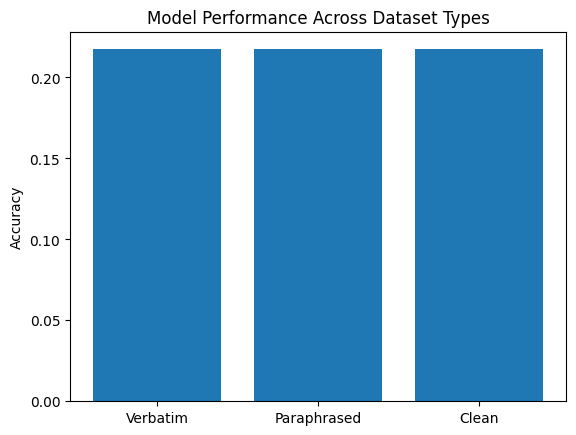

In [27]:
import matplotlib.pyplot as plt

labels = ["Verbatim", "Paraphrased", "Clean"]
scores = [acc_verbatim, acc_paraphrased, acc_clean]

plt.bar(labels, scores)
plt.ylabel("Accuracy")
plt.title("Model Performance Across Dataset Types")
plt.show()